# Business Problem and Department-wise Use

Farmers often struggle to choose the right crop because crop growth depends on soil nutrients and weather conditions. Wrong crop selection can reduce yield, increase fertilizer waste, and lower profit.

This project builds a machine learning classification model that recommends the most suitable crop based on soil and environmental data.

## Department-wise Use

### 1. Farmers
Farmers can use the model to select suitable crops before cultivation.

### 2. Agricultural Consultants
Consultants can use the model to give data-driven crop advice.

### 3. Fertilizer Companies
Fertilizer companies can understand nutrient needs and suggest fertilizer plans.

### 4. Government Agricultural Department
Government agencies can support farmers with crop planning and advisory programs.

### 5. Agri-Tech Startups
Agri-tech companies can use this model in a mobile app or web-based crop recommendation system.

#Import Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV

# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Model saving
import joblib
import warnings
warnings.filterwarnings("ignore")

# Optional XGBoost
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except:
    xgboost_available = False

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# Data Collection

The dataset used in this project is the Crop Recommendation Dataset. The dataset contains soil nutrient values and climate-related variables.

This project uses a crop recommendation dataset from Kaggle-style agricultural data sources.

## Dataset Variables

### Independent Variables
- N: Nitrogen level
- P: Phosphorus level
- K: Potassium level
- temperature: Temperature in Celsius
- humidity: Humidity percentage
- ph: Soil pH level
- rainfall: Rainfall amount

### Dependent Variable
- label: Recommended crop name

This is a classification problem because the model predicts a crop category.

In [2]:
# Load dataset
df = pd.read_csv("/content/Crop_recommendation.csv")

# Display first 5 rows
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# Data Understanding

Before preprocessing and modeling, the dataset is checked to understand its structure, number of records, number of columns, data types, and basic statistics.

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (2200, 8)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


# Data Preprocessing

Data preprocessing is required to improve data quality before model building. In this section, missing values, duplicates, outliers, encoding, and scaling are handled.



In [7]:
missing_values = df.isnull().sum()
missing_values
#The dataset is checked for missing values. If missing values are found, they should be handled using suitable methods such as mean, median, mode, or row removal depending on the situation.

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [8]:
#Duplicate Value Check
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (2200, 8)


Outlier Check

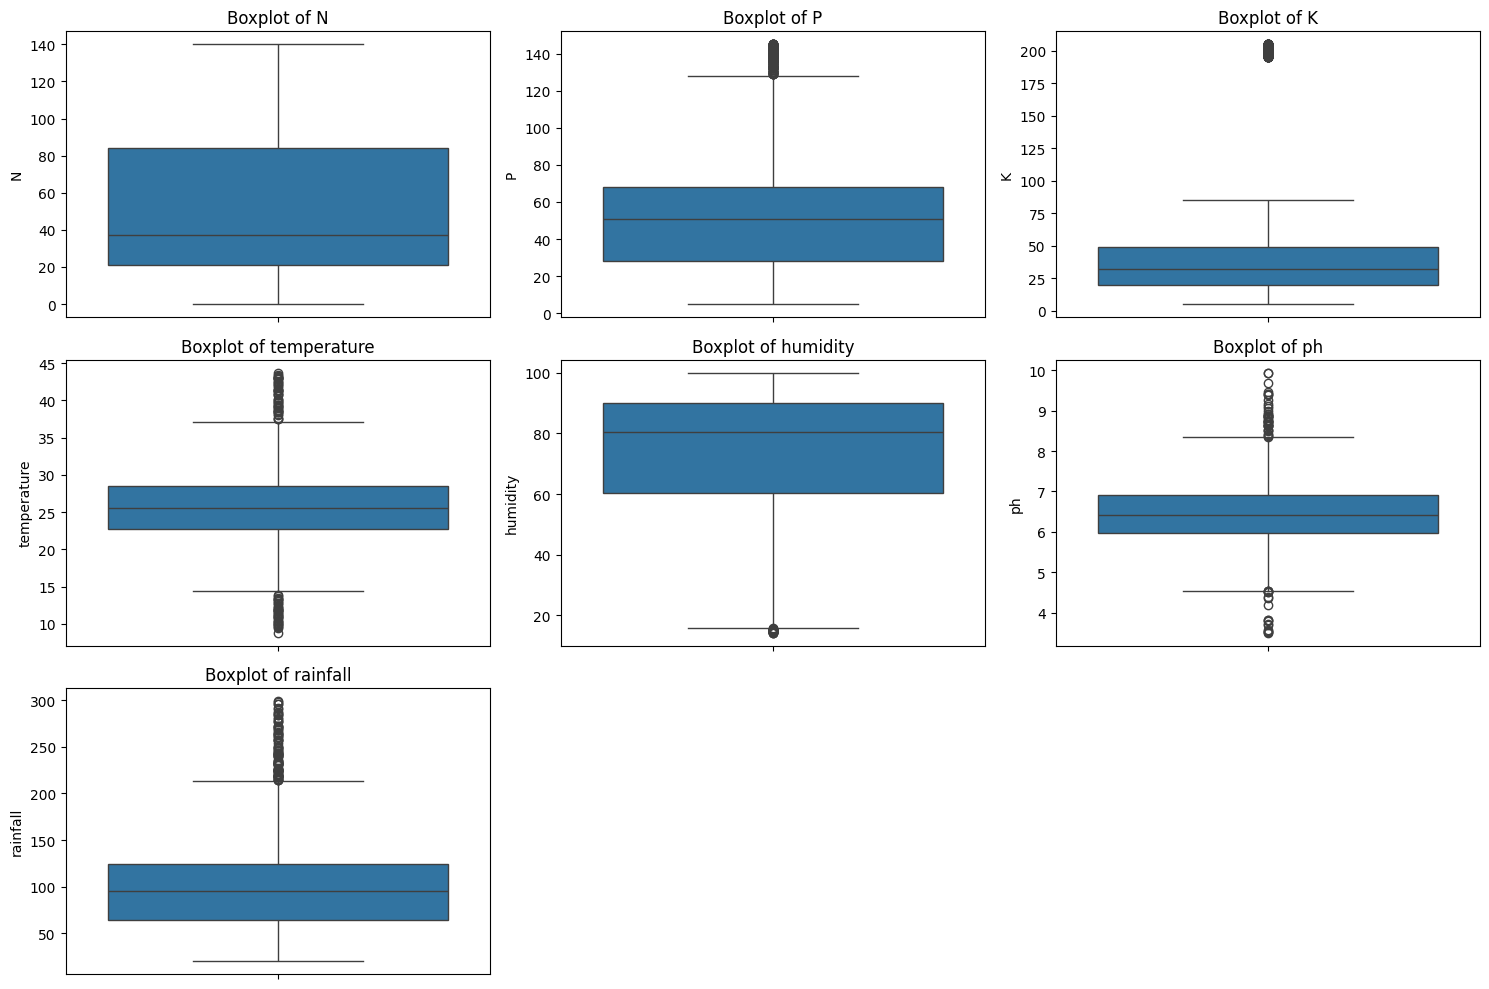

In [9]:
numeric_columns = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.show()

#Outliers are checked using boxplots. In agricultural datasets, extreme values may represent real soil or weather conditions. Therefore, outliers are not removed automatically unless they are clearly incorrect.

# Exploratory Data Analysis

Exploratory Data Analysis is used to understand patterns, distributions, and relationships in the dataset.

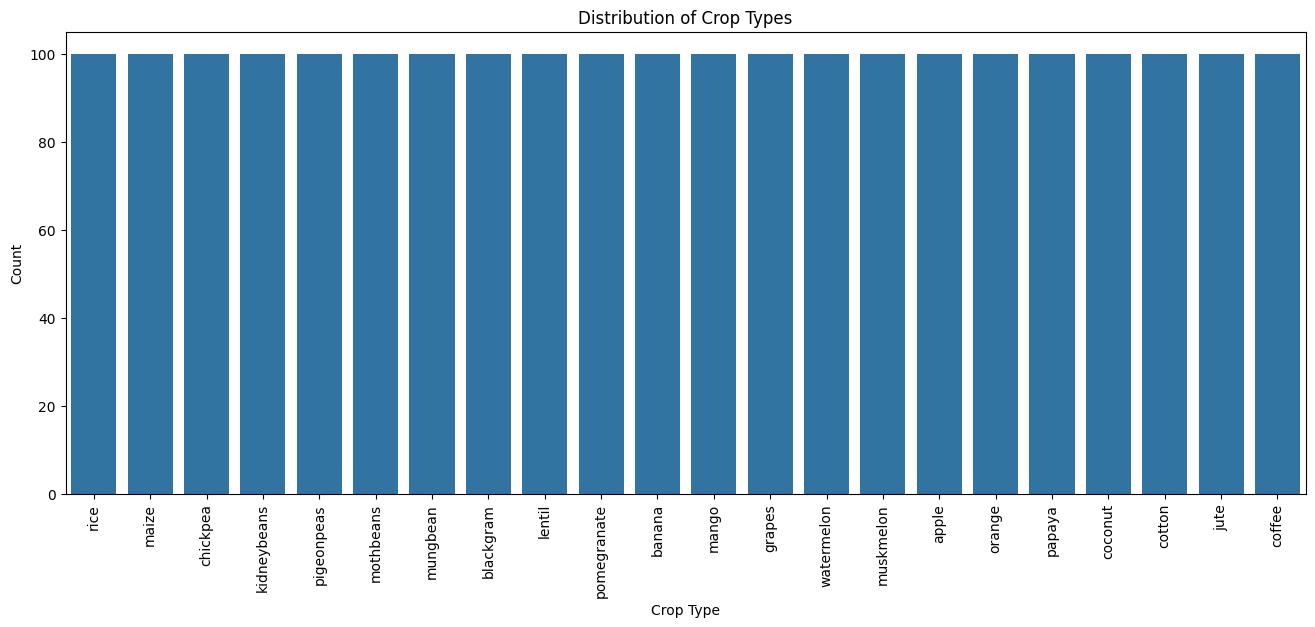

In [10]:
#Target Variable Distribution
plt.figure(figsize=(16, 6))
sns.countplot(data=df, x="label")
plt.xticks(rotation=90)
plt.title("Distribution of Crop Types")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

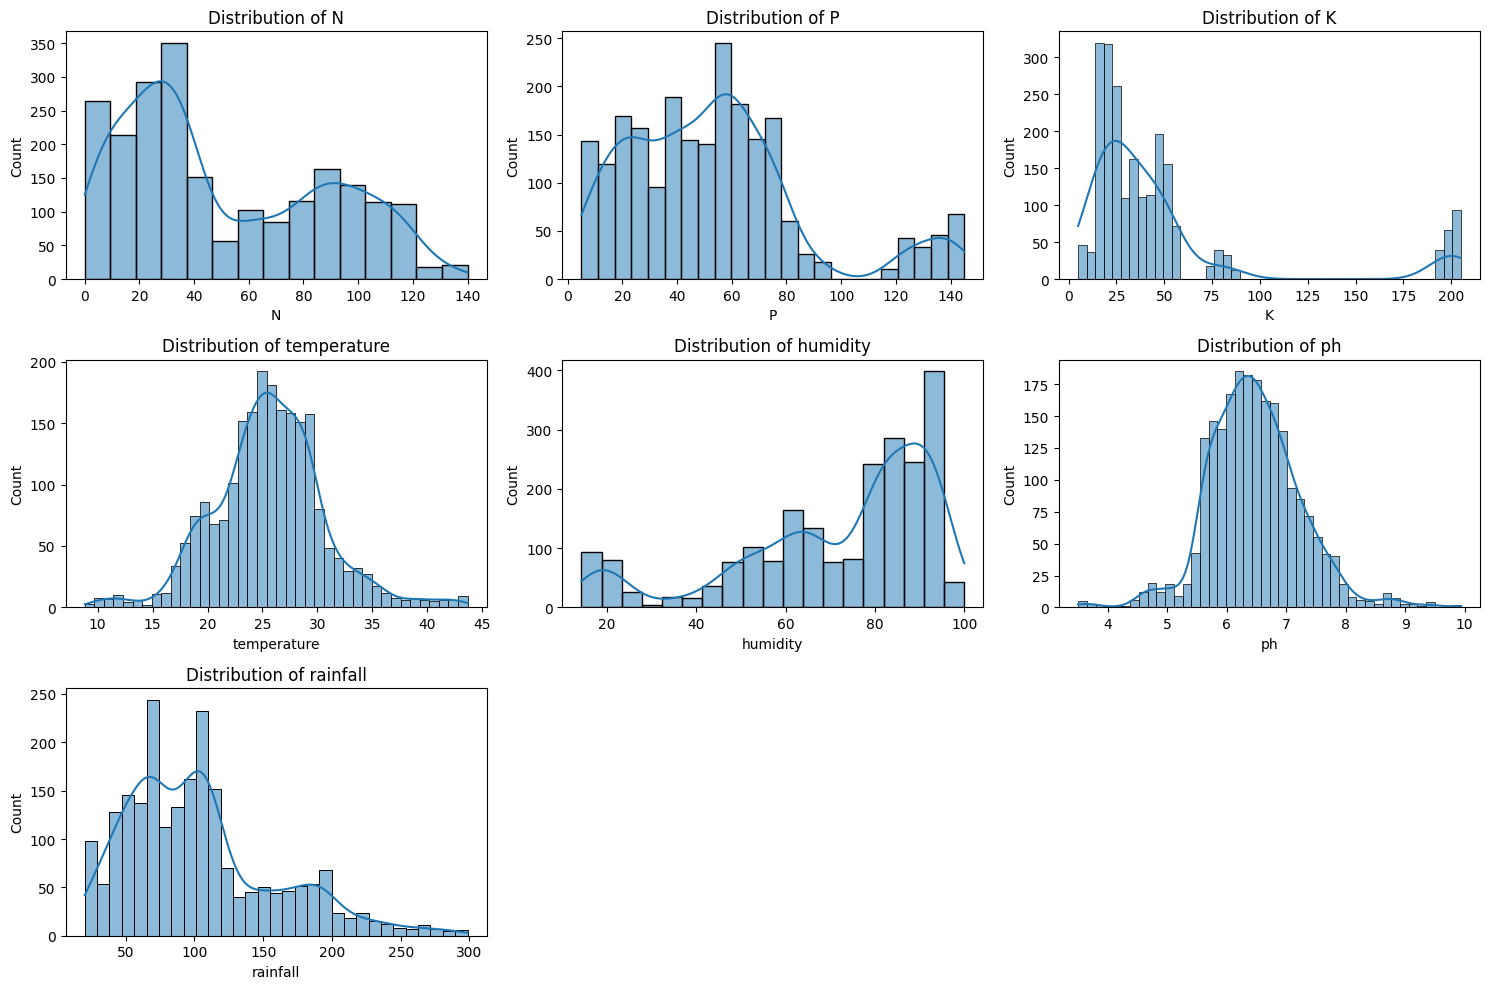

In [11]:
#Numerical Feature Distribution
plt.figure(figsize=(15, 10))

for i, col in enumerate(numeric_columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

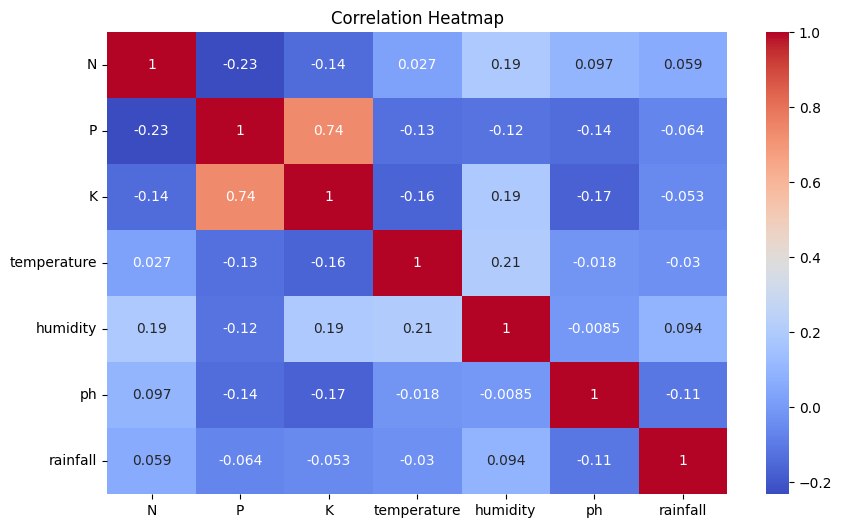

In [12]:
#Correlation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_columns].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

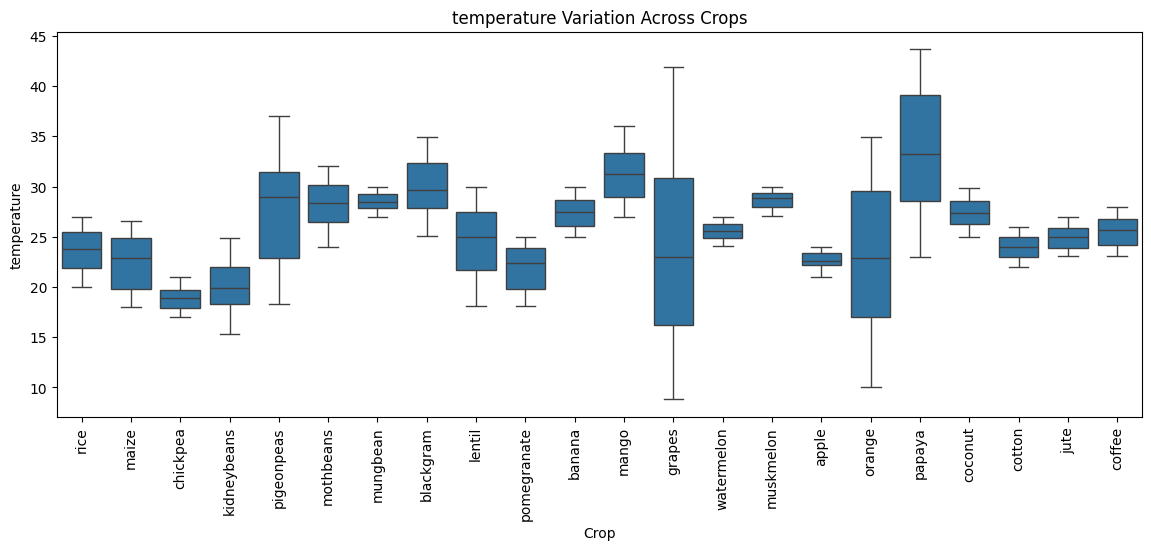

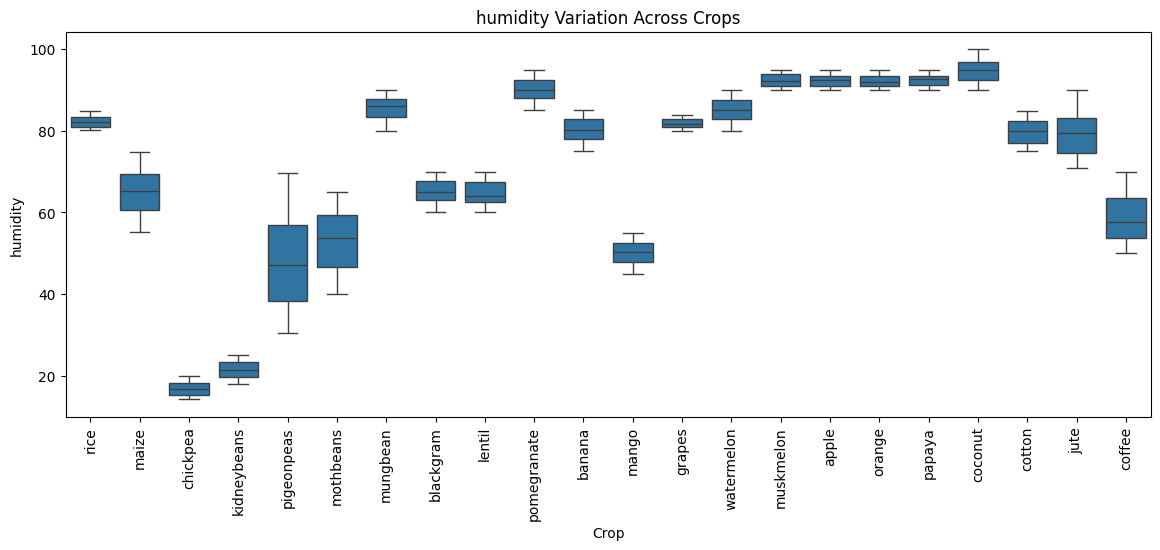

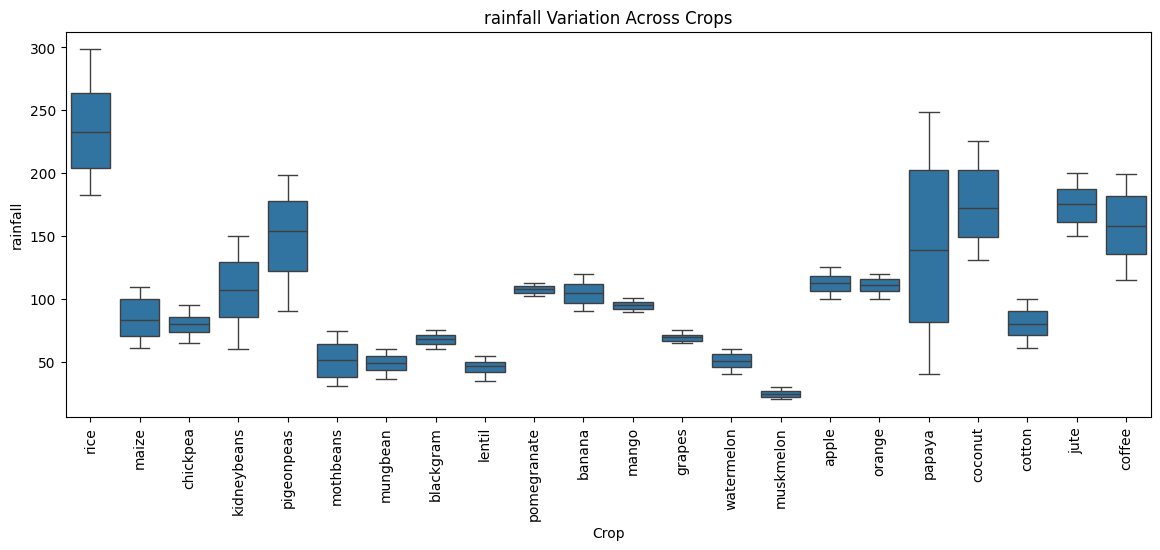

In [13]:
#Crop-wise Environmental Analysis
for feature in ["temperature", "humidity", "rainfall"]:
    plt.figure(figsize=(14, 5))
    sns.boxplot(data=df, x="label", y=feature)
    plt.xticks(rotation=90)
    plt.title(f"{feature} Variation Across Crops")
    plt.xlabel("Crop")
    plt.ylabel(feature)
    plt.show()

Crop-wise Average Requirement

In [14]:

crop_profile = df.groupby("label")[numeric_columns].mean().round(2)
crop_profile.head()

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.63,92.33,5.93,112.65
banana,100.23,82.01,50.05,27.38,80.36,5.98,104.63
blackgram,40.02,67.47,19.24,29.97,65.12,7.13,67.88
chickpea,40.09,67.79,79.92,18.87,16.86,7.34,80.06
coconut,21.98,16.93,30.59,27.41,94.84,5.98,175.69


In [15]:
for col in numeric_columns:
    print("\nTop 5 crops requiring high", col)
    print(crop_profile.sort_values(by=col, ascending=False)[col].head(5))


Top 5 crops requiring high N
label
cotton        117.77
coffee        101.20
muskmelon     100.32
banana        100.23
watermelon     99.42
Name: N, dtype: float64

Top 5 crops requiring high P
label
apple       134.22
grapes      132.53
banana       82.01
lentil       68.36
chickpea     67.79
Name: P, dtype: float64

Top 5 crops requiring high K
label
grapes        200.11
apple         199.89
chickpea       79.92
watermelon     50.22
muskmelon      50.08
Name: K, dtype: float64

Top 5 crops requiring high temperature
label
papaya       33.72
mango        31.21
blackgram    29.97
muskmelon    28.66
mungbean     28.53
Name: temperature, dtype: float64

Top 5 crops requiring high humidity
label
coconut      94.84
papaya       92.40
muskmelon    92.34
apple        92.33
orange       92.17
Name: humidity, dtype: float64

Top 5 crops requiring high ph
label
chickpea     7.34
blackgram    7.13
orange       7.02
lentil       6.93
cotton       6.91
Name: ph, dtype: float64

Top 5 crops requir

# Feature and Target Separation

The independent variables are separated from the dependent variable. The independent variables are used to predict the crop label.

In [16]:
X = df.drop("label", axis=1)
y = df["label"]

print("Independent variable shape:", X.shape)
print("Target variable shape:", y.shape)

Independent variable shape: (2200, 7)
Target variable shape: (2200,)


# Target Encoding

The crop names are text labels. Machine learning models need numerical values, so Label Encoding is used to convert crop names into numbers.

In [17]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

encoded_classes = pd.DataFrame({
    "Crop": label_encoder.classes_,
    "Encoded Value": range(len(label_encoder.classes_))
})

encoded_classes

,Crop,Encoded Value
0,apple,0
1,banana,1
2,blackgram,2
3,chickpea,3
4,coconut,4
5,coffee,5
6,cotton,6
7,grapes,7
8,jute,8
9,kidneybeans,9


# Feature Selection

Feature selection is used to identify the most important variables for crop prediction.

Here, ANOVA F-test is used to score each feature.

In [18]:
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X, y_encoded)

feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "ANOVA F-Score": selector.scores_
}).sort_values(by="ANOVA F-Score", ascending=False)

feature_scores

,Feature,ANOVA F-Score
2,K,27238.362067
4,humidity,3103.708891
1,P,1885.657859
0,N,897.568186
6,rainfall,605.527966
3,temperature,102.186981
5,ph,60.344034


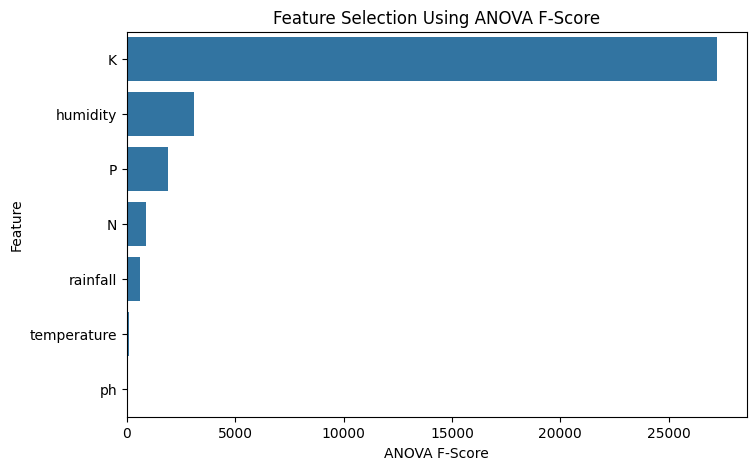

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_scores, x="ANOVA F-Score", y="Feature")
plt.title("Feature Selection Using ANOVA F-Score")
plt.show()

# Train-Test Split

The dataset is split into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate model performance on unseen data.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1760, 7)
X_test: (440, 7)
y_train: (1760,)
y_test: (440,)


# Feature Scaling

Feature scaling is used to standardize numerical features. This is important for models such as Logistic Regression because they are sensitive to feature scale.

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,N,P,K,temperature,humidity,ph,rainfall
0,-1.371628,-1.072910,-0.673510,0.819481,0.924395,0.937545,0.199440
1,-1.127411,2.084513,3.015261,0.783251,0.426613,-1.153846,-0.643677
2,-1.073140,0.536162,-0.476250,-0.879968,-2.186291,-1.107452,0.694001
3,-0.340487,-0.465713,-0.594606,0.138043,-0.459237,-0.229482,-1.231744
4,-0.883193,-1.255069,-0.791866,-2.563232,0.915842,-0.341959,0.289941


# Model Development and Justification

Multiple machine learning models are trained and compared.
## Models Used

### Logistic Regression
Used as a simple baseline classification model.

### Decision Tree
Used because it is easy to interpret and can capture non-linear relationships.

### Random Forest
Used because it combines multiple decision trees and usually gives strong performance.

### Extra Trees
Used because it is similar to Random Forest but adds more randomness, which can improve generalization.

### Gradient Boosting
Used because it builds models sequentially and improves errors step by step.

### XGBoost
Used if available because it is a powerful boosting algorithm for structured data.

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

if xgboost_available:
    models["XGBoost"] = XGBClassifier(random_state=42, eval_metric="mlogloss")

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Extra Trees': ExtraTreesClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraint

# Model Evaluation Function

The model requires classification metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC. A reusable function is created to evaluate every model consistently.

In [23]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        roc_auc = roc_auc_score(
            y_test,
            y_proba,
            multi_class="ovr",
            average="weighted"
        )
    else:
        roc_auc = np.nan

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted"),
        "ROC-AUC": roc_auc
    }

    return results

# Train and Compare Multiple Models

Each model is trained and tested using the same dataset split. This makes the comparison fair.

In [24]:
model_results = {}

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )

    model_results[model_name] = result

model_comparison = pd.DataFrame(model_results).T
model_comparison = model_comparison.sort_values(by="F1 Score", ascending=False)

model_comparison

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Extra Trees,0.995455,0.995671,0.995455,0.995452,0.999970
Random Forest,0.995455,0.995671,0.995455,0.995452,0.999995
XGBoost,0.993182,0.993506,0.993182,0.993116,0.999924
Gradient Boosting,0.988636,0.989742,0.988636,0.988723,0.999973
Decision Tree,0.979545,0.980598,0.979545,0.979423,0.989286
Logistic Regression,0.972727,0.974022,0.972727,0.972464,0.999811


<Figure size 1400x600 with 0 Axes>

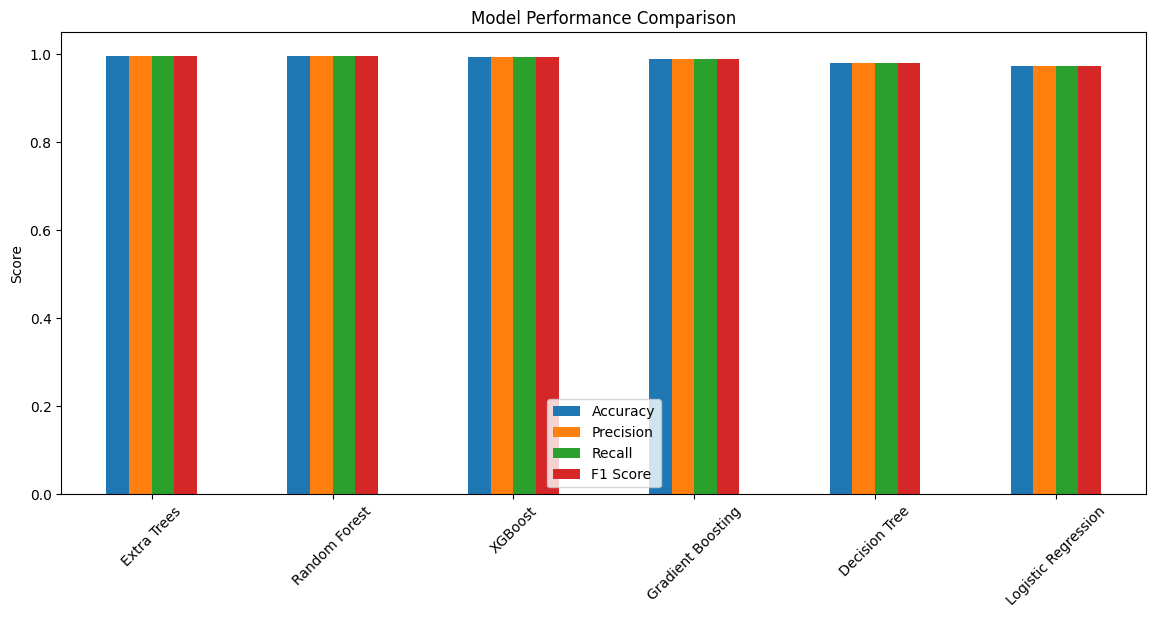

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 6))
model_comparison[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind="bar", figsize=(14, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0, 1.05)
plt.show()

# Evaluation and Validation

Cross-validation is used to check whether the model performs consistently. This gives a more reliable result than depending only on one train-test split.

In [26]:
cv_results = {}

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="f1_weighted"
    )

    cv_results[model_name] = {
        "Mean CV F1 Score": scores.mean(),
        "Standard Deviation": scores.std()
    }

cv_results_df = pd.DataFrame(cv_results).T
cv_results_df = cv_results_df.sort_values(by="Mean CV F1 Score", ascending=False)

cv_results_df

,Mean CV F1 Score,Standard Deviation
Random Forest,0.993158,0.004261
Extra Trees,0.992599,0.005860
XGBoost,0.988609,0.006504
Gradient Boosting,0.987632,0.006641
Decision Tree,0.984545,0.007273
Logistic Regression,0.967442,0.011470


# Model Optimization

Model optimization is one of the most important part. In this section, Random Forest is optimized using RandomizedSearchCV.

The goal is to find the best hyperparameter combination.

Hyperparameters tuned:

- n_estimators
- max_depth
- min_samples_split
- min_samples_leaf
- max_features

In [27]:
param_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20, 25],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_weighted",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}

Best Cross-Validation F1 Score:
0.9954467566818783


# Final Optimized Model Evaluation

The optimized Random Forest model is evaluated using test data. The final metrics show how well the model performs on unseen data.

In [28]:
best_model = random_search.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)

final_results = {
    "Accuracy": accuracy_score(y_test, y_pred_best),
    "Precision": precision_score(y_test, y_pred_best, average="weighted"),
    "Recall": recall_score(y_test, y_pred_best, average="weighted"),
    "F1 Score": f1_score(y_test, y_pred_best, average="weighted"),
    "ROC-AUC": roc_auc_score(y_test, y_proba_best, multi_class="ovr", average="weighted")
}

final_results_df = pd.DataFrame([final_results], index=["Optimized Random Forest"])
final_results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Optimized Random Forest,0.993182,0.993506,0.993182,0.993178,1.0


#Classification Report

In [29]:
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

#Confusion Matrix

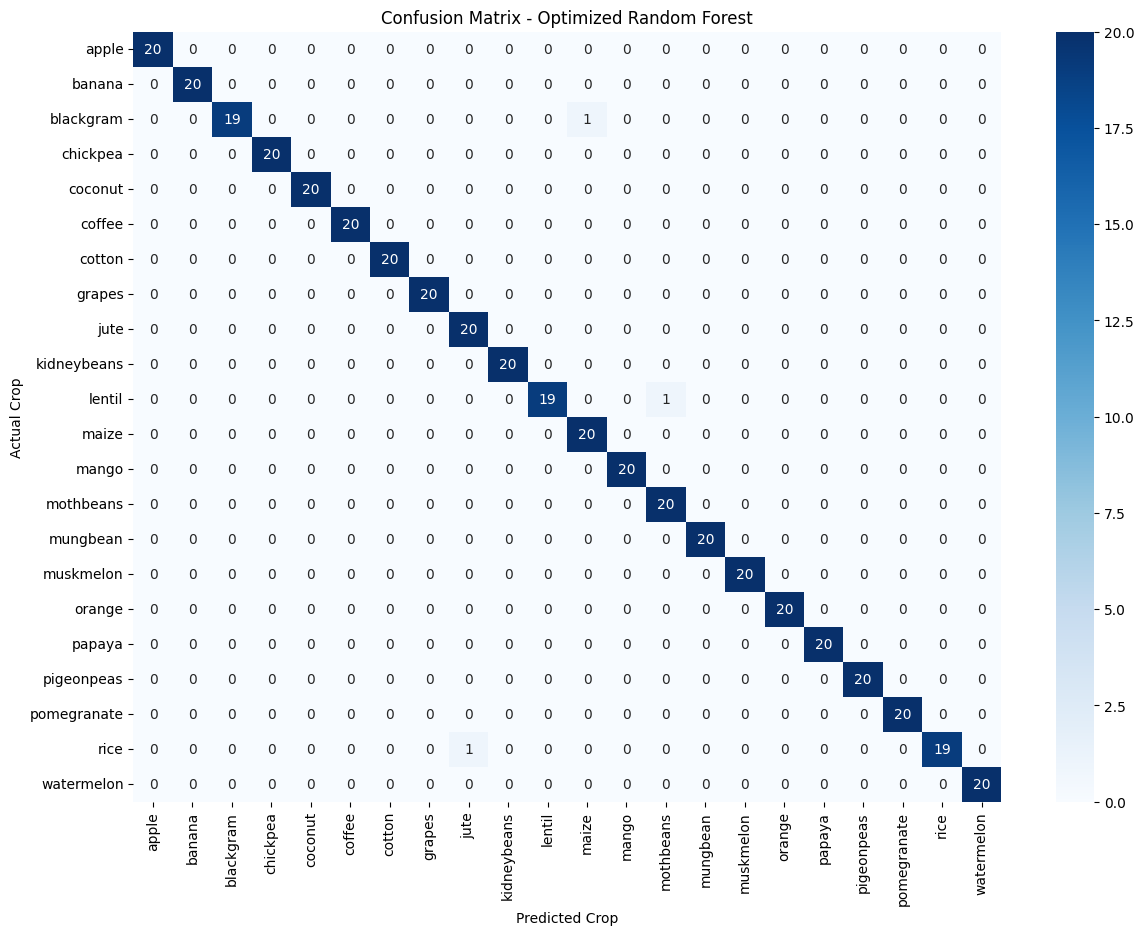

In [30]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - Optimized Random Forest")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Feature Importance

Feature importance explains which variables had the highest impact on crop recommendation. This makes the machine learning model more understandable for business users.

In [31]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
6,rainfall,0.220995
4,humidity,0.217640
2,K,0.188610
1,P,0.155380
0,N,0.102118
3,temperature,0.070294
5,ph,0.044963


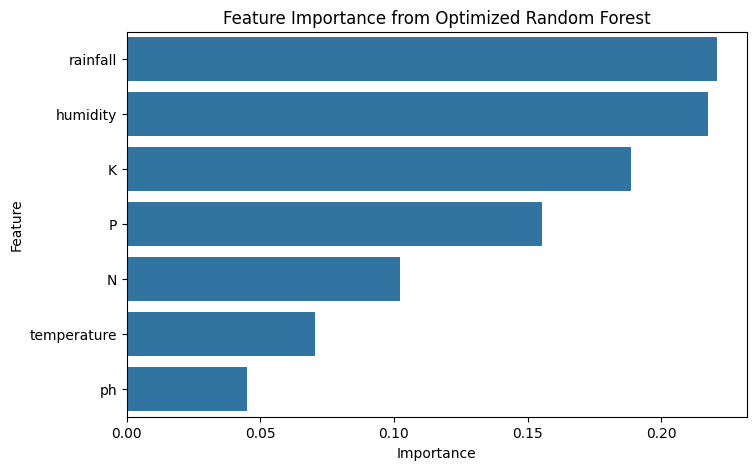

In [32]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance from Optimized Random Forest")
plt.show()

# Top 3 Crop Recommendation

Instead of recommending only one crop, this section recommends the top three suitable crops with probability scores. This makes the model more valuable because farmers may want alternative crop choices based on market price, seed availability, or seasonal risk.

In [33]:
def recommend_top_crops(N, P, K, temperature, humidity, ph, rainfall, top_n=3):
    input_data = pd.DataFrame({
        "N": [N],
        "P": [P],
        "K": [K],
        "temperature": [temperature],
        "humidity": [humidity],
        "ph": [ph],
        "rainfall": [rainfall]
    })

    input_scaled = scaler.transform(input_data)
    probabilities = best_model.predict_proba(input_scaled)[0]
    top_indices = np.argsort(probabilities)[::-1][:top_n]

    recommendations = pd.DataFrame({
        "Recommended_Crop": label_encoder.inverse_transform(top_indices),
        "Suitability_Percentage": (probabilities[top_indices] * 100).round(2)
    })

    return recommendations

In [34]:
recommend_top_crops(
    N=90,
    P=40,
    K=40,
    temperature=25,
    humidity=80,
    ph=6.5,
    rainfall=100
)

,Recommended_Crop,Suitability_Percentage
0,jute,36.39
1,rice,11.50
2,papaya,11.26


# Department-wise Decision Support

This section makes the model usable for different departments. The same prediction result can support farmers, fertilizer companies, consultants, government agencies, and agri-tech companies.

In [35]:
def department_wise_use(recommended_crop):
    department_support = {
        "Farmers": f"Farmers can consider growing {recommended_crop} because the soil and environmental conditions match this crop.",
        "Agricultural Consultants": f"Consultants can use the {recommended_crop} recommendation to provide data-driven crop advice to farmers.",
        "Fertilizer Companies": f"Fertilizer companies can prepare nutrient plans based on the expected requirements of {recommended_crop}.",
        "Government Agricultural Departments": f"Government agencies can use this type of recommendation to support farmer advisory programs and crop planning.",
        "Agri-Tech Startups": f"Agri-tech startups can use this model in a mobile or web application for smart crop recommendation."
    }

    return pd.DataFrame(
        list(department_support.items()),
        columns=["Department", "Decision Support"]
    )

In [36]:
sample_recommendation = recommend_top_crops(
    N=90,
    P=40,
    K=40,
    temperature=25,
    humidity=80,
    ph=6.5,
    rainfall=100
)

top_crop = sample_recommendation.iloc[0]["Recommended_Crop"]

department_wise_use(top_crop)

,Department,Decision Support
0,Farmers,Farmers can consider growing jute because the ...
1,Agricultural Consultants,Consultants can use the jute recommendation to...
2,Fertilizer Companies,Fertilizer companies can prepare nutrient plan...
3,Government Agricultural Departments,Government agencies can use this type of recom...
4,Agri-Tech Startups,Agri-tech startups can use this model in a mob...


# Soil and Nutrient Advisory

This section adds a simple advisory system. It gives basic soil and nutrient suggestions along with the crop recommendation.

In [37]:
def soil_advisory(N, P, K, ph):
    advice = []

    if N < 50:
        advice.append("Nitrogen level is low. Nitrogen-based fertilizer may be needed.")
    elif N > 100:
        advice.append("Nitrogen level is high. Extra nitrogen fertilizer should be avoided.")
    else:
        advice.append("Nitrogen level is moderate.")

    if P < 30:
        advice.append("Phosphorus level is low. Phosphorus support may help root development.")
    elif P > 80:
        advice.append("Phosphorus level is high. Additional phosphorus may not be needed.")
    else:
        advice.append("Phosphorus level is moderate.")

    if K < 30:
        advice.append("Potassium level is low. Potassium fertilizer may improve crop strength.")
    elif K > 80:
        advice.append("Potassium level is high. Extra potassium may not be needed.")
    else:
        advice.append("Potassium level is moderate.")

    if ph < 5.5:
        advice.append("Soil is acidic. Lime treatment may be considered.")
    elif ph > 7.5:
        advice.append("Soil is alkaline. Soil treatment may be needed depending on crop choice.")
    else:
        advice.append("Soil pH is suitable for many crops.")

    return advice

In [38]:
soil_advice = soil_advisory(N=90, P=40, K=40, ph=6.5)

for item in soil_advice:
    print("-", item)

- Nitrogen level is moderate.
- Phosphorus level is moderate.
- Potassium level is moderate.
- Soil pH is suitable for many crops.


# Crop Suitability Recommendation System

This section makes the model more practical and unique. Instead of only predicting one crop, the model also shows the top three suitable crops with probability scores.

This is useful in real business situations because farmers may want alternatives based on market price, seed availability, season, and farming cost.

In [39]:
def sustainability_output(recommended_crop, N, P, K, rainfall, ph):
    sustainability_notes = []

    sustainability_notes.append(
        f"{recommended_crop} can support better land-use planning because it matches the given soil and climate conditions."
    )

    if 5.5 <= ph <= 7.5:
        sustainability_notes.append(
            "The soil pH is within a suitable range, which may reduce the need for heavy chemical soil correction."
        )
    else:
        sustainability_notes.append(
            "The soil pH may need correction, so sustainable soil treatment should be considered before cultivation."
        )

    if N <= 100 and P <= 80 and K <= 80:
        sustainability_notes.append(
            "The nutrient levels are not extremely high, so fertilizer use can be managed carefully to reduce waste."
        )
    else:
        sustainability_notes.append(
            "Some nutrient levels are high, so fertilizer application should be controlled to avoid overuse."
        )

    if rainfall >= 80:
        sustainability_notes.append(
            "Rainfall support is relatively good, which may reduce dependency on artificial irrigation."
        )
    else:
        sustainability_notes.append(
            "Rainfall is relatively low, so efficient irrigation planning is recommended."
        )

    sustainability_notes.append(
        "Overall, the recommendation can help reduce input waste, improve crop suitability, and support more sustainable farming decisions."
    )

    return sustainability_notes

In [40]:
# Example prediction
recommend_top_crops(
    N=90,
    P=40,
    K=40,
    temperature=25,
    humidity=80,
    ph=6.5,
    rainfall=100
)

,Recommended_Crop,Suitability_Percentage
0,jute,36.39
1,rice,11.50
2,papaya,11.26


## 22.5 Final Combined Crop Recommendation System

This final function combines all four  parts into one practical decision-support system.

It produces:

1. Top crop recommendations
2. Soil advisory
3. Department-wise decision support
4. Sustainability output

In [41]:
def final_crop_recommendation_result(N, P, K, temperature, humidity, ph, rainfall):
    print("Crop Recommendation Result")
    print("--------------------------")

    recommendations = recommend_top_crops(
        N=N,
        P=P,
        K=K,
        temperature=temperature,
        humidity=humidity,
        ph=ph,
        rainfall=rainfall,
        top_n=3
    )

    print("\nTop Crop Recommendations:")
    display(recommendations)

    print("\nSoil Advisory:")
    advice = soil_advisory(N, P, K, ph)
    for item in advice:
        print("-", item)

    top_crop = recommendations.iloc[0]["Recommended_Crop"]

    print("\nDepartment-wise Decision Support:")
    display(department_wise_use(top_crop))

    print("\nSustainability Output:")
    sustainability_notes = sustainability_output(top_crop, N, P, K, rainfall, ph)
    for note in sustainability_notes:
        print("-", note)

In [42]:
final_crop_recommendation_result(
    N=90,
    P=40,
    K=40,
    temperature=25,
    humidity=80,
    ph=6.5,
    rainfall=100
)

Crop Recommendation Result
--------------------------

Top Crop Recommendations:


,Recommended_Crop,Suitability_Percentage
0,jute,36.39
1,rice,11.50
2,papaya,11.26



Soil Advisory:
- Nitrogen level is moderate.
- Phosphorus level is moderate.
- Potassium level is moderate.
- Soil pH is suitable for many crops.

Department-wise Decision Support:


,Department,Decision Support
0,Farmers,Farmers can consider growing jute because the ...
1,Agricultural Consultants,Consultants can use the jute recommendation to...
2,Fertilizer Companies,Fertilizer companies can prepare nutrient plan...
3,Government Agricultural Departments,Government agencies can use this type of recom...
4,Agri-Tech Startups,Agri-tech startups can use this model in a mob...



Sustainability Output:
- jute can support better land-use planning because it matches the given soil and climate conditions.
- The soil pH is within a suitable range, which may reduce the need for heavy chemical soil correction.
- The nutrient levels are not extremely high, so fertilizer use can be managed carefully to reduce waste.
- Rainfall support is relatively good, which may reduce dependency on artificial irrigation.
- Overall, the recommendation can help reduce input waste, improve crop suitability, and support more sustainable farming decisions.


# Business Insights and Recommendations

The machine learning model shows that crop recommendation can be improved by using soil nutrients and climate-related data. Features such as nitrogen, phosphorus, potassium, temperature, humidity, pH, and rainfall help identify suitable crops.

## Key Insights

1. Soil nutrients and weather conditions are important for crop selection.
2. The model can reduce guesswork in farming decisions.
3. Top 3 crop recommendations are more useful than only one prediction.
4. Department-wise use makes the model practical for farmers, consultants, fertilizer companies, government agencies, and agri-tech businesses.

## Recommendations

Farmers should test soil conditions before selecting crops. Agricultural consultants can use this model to provide more accurate crop advice. Fertilizer companies can combine this system with nutrient-based fertilizer plans. Government agencies can use this type of model to support rural farmers. Agri-tech companies can build a mobile application using this model.

However, the final crop decision should also consider market price, seed availability, farming cost, irrigation facility, and seasonal risk.

# Limitations and Future Improvements

## Limitations

1. The dataset may not represent every region or country.
2. The model does not include market price.
3. The model does not include seed cost, labor cost, or fertilizer cost.
4. The model does not include pest or disease risk.
5. The model depends on accurate soil and weather input.

## Future Improvements

1. Add real-time weather data.
2. Add crop market price data.
3. Add region-specific soil data.
4. Add profit prediction.
5. Build a mobile or web application.
6. Use explainable AI methods such as SHAP for deeper interpretation.

In [43]:
joblib.dump(best_model, "final_crop_recommendation_model.pkl")
joblib.dump(scaler, "crop_scaler.pkl")
joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("Final model, scaler, and label encoder saved successfully.")

Final model, scaler, and label encoder saved successfully.


# 23. Interactive Testing with User Input

This section allows users to input their own soil and environmental values and get real-time crop recommendations and advisory.

This makes the system more practical because farmers or users can directly test different scenarios.

The system will:

1. Take input values from the user
2. Run the trained machine learning model
3. Show:
   - Top 3 crop recommendations
   - Soil advisory
   - Department-wise decision support
   - Sustainability output

In [44]:
def user_input_test():
    print("Enter Soil and Environmental Values")
    print("-----------------------------------")

    N = float(input("Enter Nitrogen (N) value: "))
    P = float(input("Enter Phosphorus (P) value: "))
    K = float(input("Enter Potassium (K) value: "))
    temperature = float(input("Enter Temperature (°C): "))
    humidity = float(input("Enter Humidity (%): "))
    ph = float(input("Enter pH value: "))
    rainfall = float(input("Enter Rainfall (mm): "))

    print("\nProcessing your input...\n")

    final_crop_recommendation_result(
        N=N,
        P=P,
        K=K,
        temperature=temperature,
        humidity=humidity,
        ph=ph,
        rainfall=rainfall
    )

In [46]:
user_input_test()

Enter Soil and Environmental Values
-----------------------------------
Enter Nitrogen (N) value: 12
Enter Phosphorus (P) value: 21
Enter Potassium (K) value: 21
Enter Temperature (°C): 31
Enter Humidity (%): 50
Enter pH value: 4
Enter Rainfall (mm): 222

Processing your input...

Crop Recommendation Result
--------------------------

Top Crop Recommendations:


,Recommended_Crop,Suitability_Percentage
0,pigeonpeas,34.05
1,mango,33.56
2,coconut,13.54



Soil Advisory:
- Nitrogen level is low. Nitrogen-based fertilizer may be needed.
- Phosphorus level is low. Phosphorus support may help root development.
- Potassium level is low. Potassium fertilizer may improve crop strength.
- Soil is acidic. Lime treatment may be considered.

Department-wise Decision Support:


,Department,Decision Support
0,Farmers,Farmers can consider growing pigeonpeas becaus...
1,Agricultural Consultants,Consultants can use the pigeonpeas recommendat...
2,Fertilizer Companies,Fertilizer companies can prepare nutrient plan...
3,Government Agricultural Departments,Government agencies can use this type of recom...
4,Agri-Tech Startups,Agri-tech startups can use this model in a mob...



Sustainability Output:
- pigeonpeas can support better land-use planning because it matches the given soil and climate conditions.
- The soil pH may need correction, so sustainable soil treatment should be considered before cultivation.
- The nutrient levels are not extremely high, so fertilizer use can be managed carefully to reduce waste.
- Rainfall support is relatively good, which may reduce dependency on artificial irrigation.
- Overall, the recommendation can help reduce input waste, improve crop suitability, and support more sustainable farming decisions.


In [47]:
import joblib

joblib.dump(best_model, "final_crop_recommendation_model.pkl")
joblib.dump(scaler, "crop_scaler.pkl")
joblib.dump(label_encoder, "crop_label_encoder.pkl")

print("Model files saved successfully.")

Model files saved successfully.
